

# Wind Power Capacity Factor Analysis — Germany 2024

## Overview

This project is a first pilot analysis of wind power data using an
ERA5-derived dataset from the Pan-European Climate Database (PECD).

The analysis focuses on Germany (DE) during 2024 and examines the
temporal variability of wind power capacity factor.

The main objectives are:

- Calculate basic statistics of wind power capacity factor
- Examine the hourly capacity-factor distribution
- Analyse monthly and seasonal variability
- Create a capacity-factor duration curve
- Estimate annual energy production for an example installed capacity

This project was developed as an introductory Python exercise for
applying meteorological data analysis concepts to wind energy.

# Wind Power Capacity Factor Analysis — Germany 2024

## Overview

This project is a first pilot analysis of wind power data using an
ERA5-derived dataset from the Pan-European Climate Database (PECD).

The analysis focuses on Germany (DE) during 2024 and examines the
temporal variability of wind power capacity factor.

The main objectives are:

- Calculate basic statistics of wind power capacity factor
- Examine the hourly capacity-factor distribution
- Analyse monthly and seasonal variability
- Create a capacity-factor duration curve
- Estimate annual energy production for an example installed capacity

This project was developed as an introductory Python exercise for
applying meteorological data analysis concepts to wind energy.

## Dataset

The dataset used in this project is derived from ERA5 reanalysis and
provided through the Pan-European Climate Database (PECD).

The CSV contains hourly wind-power capacity-factor data for multiple
European and surrounding countries.

For this analysis, the `DE` column is used to represent Germany.

### Temporal coverage

- Year: 2024
- Temporal resolution: Hourly
- Number of hourly observations: 8,784

2024 is a leap year, therefore:

\[
366 \times 24 = 8,784
\]

### Important note

The values in the `DE` column represent wind-power capacity factor,
not wind speed.

Capacity factor is expressed as a fraction between 0 and 1:

\[
CF = \frac{P_{actual}}{P_{rated}}
\]

For example:

\[
CF = 0.54 = 54\%
\]

## Methodology

The analysis follows a simple time-series workflow:

1. Load the PECD CSV dataset
2. Remove the metadata section of the file
3. Select Germany (`DE`)
4. Convert the date column to datetime
5. Convert capacity-factor values to numeric format
6. Calculate descriptive statistics
7. Analyse hourly, monthly and seasonal variability
8. Calculate the annual mean capacity factor
9. Create a capacity-factor duration curve
10. Estimate annual energy production for an assumed installed capacity

The analysis is intentionally kept simple because this is an introductory
wind-energy data-analysis project.

## Data limitations

This project uses an ERA5-derived PECD wind-power capacity-factor
dataset rather than measured wind-farm SCADA data.

Therefore, the results should not be interpreted as a bankable wind
resource assessment or as actual measured German wind-farm production.

The analysis is intended as a demonstration of basic wind-energy
time-series analysis using reanalysis-derived data.

The capacity factor is already derived through the PECD wind-power
modelling methodology. Therefore, this project does not independently
calculate turbine power from raw wind speed.

In [34]:
# Install required package
!pip install windrose

In [35]:
# ================================
# 1. Import libraries
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
# ================================
# 2. Load the PECD data
# ================================

url = "https://raw.githubusercontent.com/Hanifahmed/wind_analysis_project/main/data/ERA5_Wind_2024.csv"

# Read the file after the metadata section
raw = pd.read_csv(
    url,
    skiprows=52,
    header=None
)

# Split the comma-separated data
df_site = raw.iloc[:, 0].str.split(",", expand=True)

# First row contains the column names
df_site.columns = df_site.iloc[0]

# Remove the header row from the data
df_site = df_site.iloc[1:].reset_index(drop=True)

print(df_site.head())

0                 Date AL                  AT                  BA  \
0  2024-01-01 00:00:00     0.2063861163582084              0.8707   
1  2024-01-01 01:00:00      0.352645182485223  0.8623000000000001   
2  2024-01-01 02:00:00     0.4827469549455586              0.8289   
3  2024-01-01 03:00:00     0.4335562429819286  0.7590999999999999   
4  2024-01-01 04:00:00     0.4110918847397729              0.8085   

0                  BE                  BG      CH      CY                  CZ  \
0  0.8900066914099716  0.1319031197301855  0.6366     0.0  0.2374335970122919   
1  0.8896723158145444  0.1269950252951096  0.5999     0.0  0.2847286537669823   
2   0.888786760082566  0.1150024451939291   0.605     0.0  0.2963637563959301   
3  0.8855744430771674  0.1027368465430016  0.5969  0.0001  0.3017635623125331   
4   0.883555244919022  0.0888921585160202  0.5808  0.0004  0.3306854378639063   

0                  DE  ...      RS                  SE      SI  \
0  0.5392137437016028  ...   0.7

In [37]:
# ================================
# 3. Select Germany
# ================================

df_site = df_site[["Date", "DE"]].copy()

# Rename columns
df_site.columns = ["time", "capacity_factor"]

print(df_site.head())

                  time     capacity_factor
0  2024-01-01 00:00:00  0.5392137437016028
1  2024-01-01 01:00:00  0.5387895914847943
2  2024-01-01 02:00:00  0.5508961189479994
3  2024-01-01 03:00:00  0.5582739079259956
4  2024-01-01 04:00:00  0.5498903414597818


In [38]:
# ================================
# 4. Prepare the time information
# ================================

df_site["time"] = pd.to_datetime(df_site["time"])

# Convert capacity factor to numeric
df_site["capacity_factor"] = pd.to_numeric(
    df_site["capacity_factor"],
    errors="coerce"
)

# Set time as index
df_site = df_site.set_index("time")

print(df_site.head())

                     capacity_factor
time                                
2024-01-01 00:00:00         0.539214
2024-01-01 01:00:00         0.538790
2024-01-01 02:00:00         0.550896
2024-01-01 03:00:00         0.558274
2024-01-01 04:00:00         0.549890


In [39]:
# ================================
# 5. Check the data
# ================================

print("Number of observations:")
print(len(df_site))

print("\nData type:")
print(df_site["capacity_factor"].dtype)

print("\nMissing values:")
print(df_site["capacity_factor"].isna().sum())

print("\nMinimum capacity factor:")
print(df_site["capacity_factor"].min())

print("\nMaximum capacity factor:")
print(df_site["capacity_factor"].max())

Number of observations:
8784

Data type:
float64

Missing values:
0

Minimum capacity factor:
6.112509008570602e-05

Maximum capacity factor:
0.8459064910212972


In [40]:
# ================================
# 6. Convert capacity factor to %
# ================================

df_site["capacity_factor_percent"] = (
    df_site["capacity_factor"] * 100
)

print(df_site.head())

                     capacity_factor  capacity_factor_percent
time                                                         
2024-01-01 00:00:00         0.539214                53.921374
2024-01-01 01:00:00         0.538790                53.878959
2024-01-01 02:00:00         0.550896                55.089612
2024-01-01 03:00:00         0.558274                55.827391
2024-01-01 04:00:00         0.549890                54.989034


In [41]:
# ================================
# 7. Capacity factor statistics
# ================================

print(
    df_site["capacity_factor_percent"].describe()
)

count    8784.000000
mean       22.883988
std        19.271672
min         0.006113
25%         7.925682
50%        16.879503
75%        33.202992
max        84.590649
Name: capacity_factor_percent, dtype: float64


In [42]:
# ================================
# 8. Annual average capacity factor
# ================================

annual_cf = df_site["capacity_factor"].mean()

print(
    "Average capacity factor:",
    round(annual_cf * 100, 2),
    "%"
)

Average capacity factor: 22.88 %


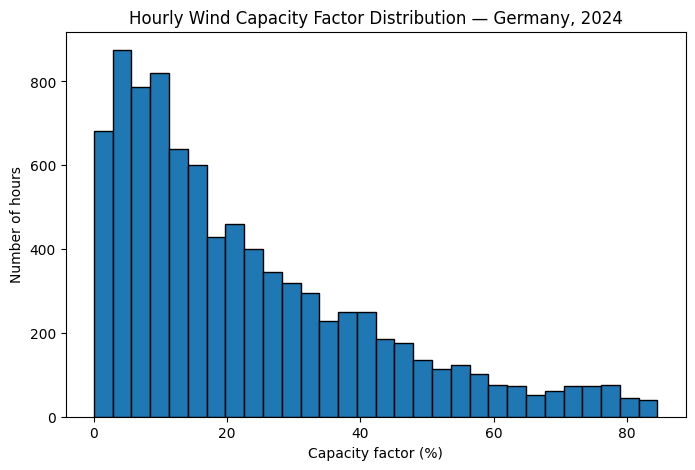

In [43]:
# ================================
# 9. Capacity factor distribution
# ================================

plt.figure(figsize=(8, 5))

plt.hist(
    df_site["capacity_factor_percent"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Capacity factor (%)")
plt.ylabel("Number of hours")
plt.title("Hourly Wind Capacity Factor Distribution — Germany, 2024")

plt.show()

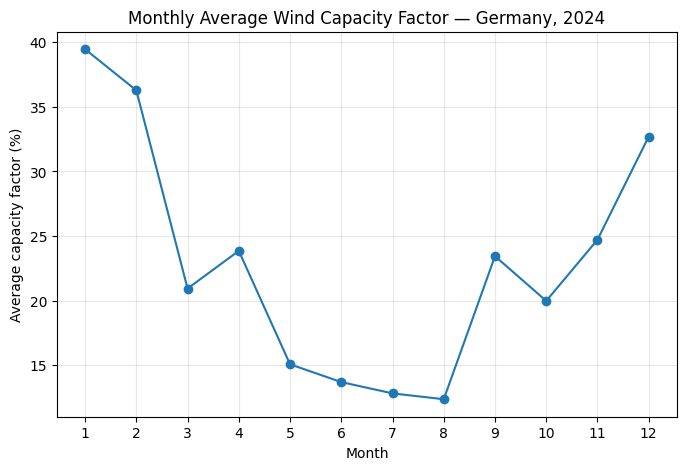

In [44]:
# ================================
# 10. Monthly capacity factor
# ================================

monthly_cf = (
    df_site["capacity_factor"]
    .groupby(df_site.index.month)
    .mean()
)

monthly_cf_percent = monthly_cf * 100

plt.figure(figsize=(8, 5))

plt.plot(
    monthly_cf_percent.index,
    monthly_cf_percent.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average capacity factor (%)")
plt.title("Monthly Average Wind Capacity Factor — Germany, 2024")

plt.xticks(range(1, 13))

plt.grid(alpha=0.3)

plt.show()

season
Autumn    22.678131
Spring    19.905996
Summer    12.944017
Winter    36.149764
Name: capacity_factor, dtype: float64


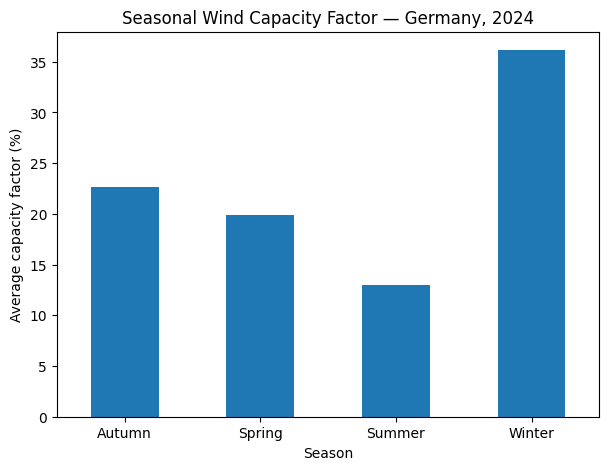

In [46]:
# ================================
# 11. Seasonal capacity factor
# ================================

df_site["season"] = df_site.index.month.map({
    12: "Winter",
    1: "Winter",
    2: "Winter",

    3: "Spring",
    4: "Spring",
    5: "Spring",

    6: "Summer",
    7: "Summer",
    8: "Summer",

    9: "Autumn",
    10: "Autumn",
    11: "Autumn"
})

seasonal_cf = (
    df_site
    .groupby("season")["capacity_factor"]
    .mean()
    * 100
)

print(seasonal_cf)
# ================================
# capacity factor plot
# ================================
plt.figure(figsize=(7, 5))

seasonal_cf.plot(
    kind="bar"
)

plt.xlabel("Season")
plt.ylabel("Average capacity factor (%)")
plt.title("Seasonal Wind Capacity Factor — Germany, 2024")

plt.xticks(rotation=0)

plt.show()

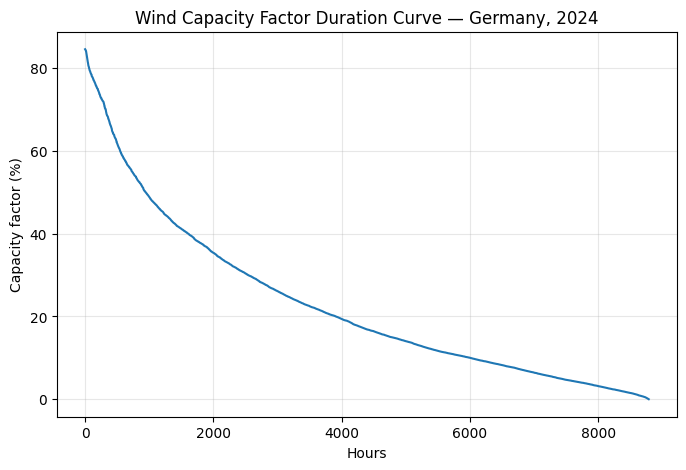

In [47]:
# ================================
# 12. Capacity factor duration curve
# ================================

sorted_cf = np.sort(
    df_site["capacity_factor_percent"]
)[::-1]

hours = np.arange(
    1,
    len(sorted_cf) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    hours,
    sorted_cf
)

plt.xlabel("Hours")
plt.ylabel("Capacity factor (%)")
plt.title("Wind Capacity Factor Duration Curve — Germany, 2024")

plt.grid(alpha=0.3)

plt.show()

In [48]:
# ================================
# 13. Simple AEP calculation
# ================================

installed_capacity = 100  # MW
hours_per_year = 8760

AEP = (
    annual_cf
    * installed_capacity
    * hours_per_year
)

print(
    "Assumed installed capacity:",
    installed_capacity,
    "MW"
)

print(
    "Estimated annual energy production:",
    round(AEP, 1),
    "MWh/year"
)

print(
    "Estimated annual energy production:",
    round(AEP / 1000, 2),
    "GWh/year"
)

Assumed installed capacity: 100 MW
Estimated annual energy production: 200463.7 MWh/year
Estimated annual energy production: 200.46 GWh/year


In [50]:
# ================================
# 14. Project summary
# ================================

print("======================================")
print("WIND POWER CAPACITY FACTOR SUMMARY")
print("======================================")

print(
    "Study area: Germany"
)

print(
    "Year: 2024"
)

print(
    "Number of observations:",
    len(df_site)
)

print(
    "Mean capacity factor:",
    round(annual_cf * 100, 2),
    "%"
)

print(
    "Minimum capacity factor:",
    round(df_site["capacity_factor"].min() * 100, 2),
    "%"
)

print(
    "Maximum capacity factor:",
    round(df_site["capacity_factor"].max() * 100, 2),
    "%"
)

WIND POWER CAPACITY FACTOR SUMMARY
Study area: Germany
Year: 2024
Number of observations: 8784
Mean capacity factor: 22.88 %
Minimum capacity factor: 0.01 %
Maximum capacity factor: 84.59 %


## Conclusion

The analysis demonstrates the temporal variability of ERA5-derived
wind-power capacity factor for Germany during 2024.

The results show substantial hourly variability in potential wind-power
production, together with clear monthly and seasonal differences.

The annual mean capacity factor provides a simple indicator of the
overall wind-power resource represented by the dataset.

This pilot project provides a foundation for future work involving
higher-resolution spatial analysis, multiple years of ERA5 data,
wind-resource assessment, and comparison between different regions.